In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from preprocessing import load_and_split
from preprocessing import build_preprocessor

In [2]:
x_train, x_test, y_train, y_test = load_and_split("../data/student-mat.csv")

pipeline = Pipeline([
    ("preprocessing", build_preprocessor()),
    ("model", RandomForestRegressor(
        n_estimators=200,
    max_depth=5,

    random_state=42))
])
pipeline.fit(x_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [3]:
y_pred = pipeline.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Kết quả đánh giá mô hình (các metrics) ---")
print(f"MAE (Sai số tuyệt đối trung bình): {mae:.4f}")
print(f"RMSE (Căn bậc hai sai số toàn phương): {rmse:.4f}")
print(f"R2 Score (Độ phù hợp): {r2:.4f}")

--- Kết quả đánh giá mô hình (các metrics) ---
MAE (Sai số tuyệt đối trung bình): 1.5292
RMSE (Căn bậc hai sai số toàn phương): 2.0268
R2 Score (Độ phù hợp): 0.7997


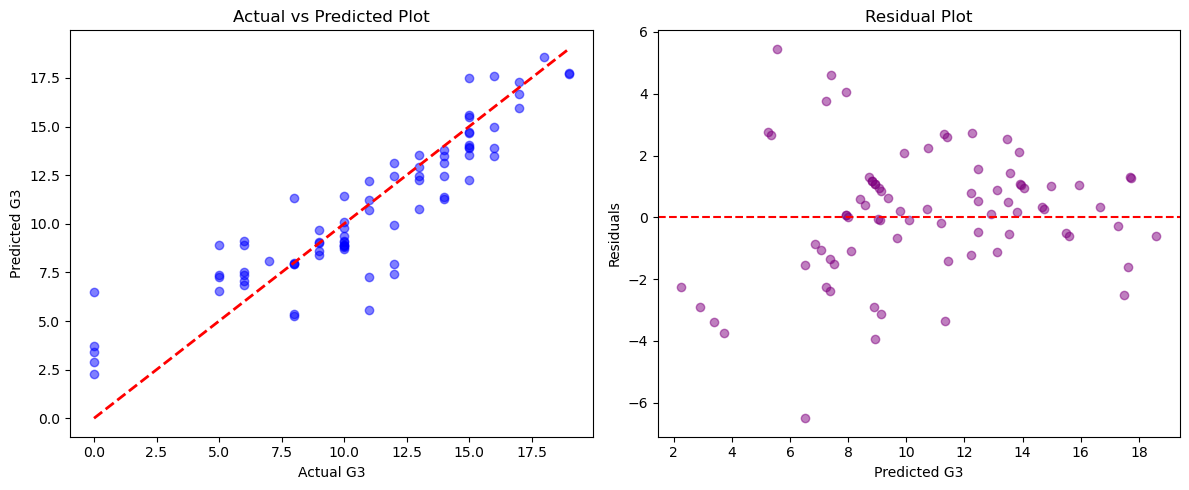

In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs Predicted Plot')

plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted G3')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

Biểu đồ Actual vs Predicted Plot cho thấy hầu hết các điểm nằm gần đường chéo y=x, và ở biểu đồ Residual Plot, các điểm phân bố ngẫu nhiên về cả 2 phía của đường nằm ngang. Điều này cho thấy mô hình hoạt động bình thường.

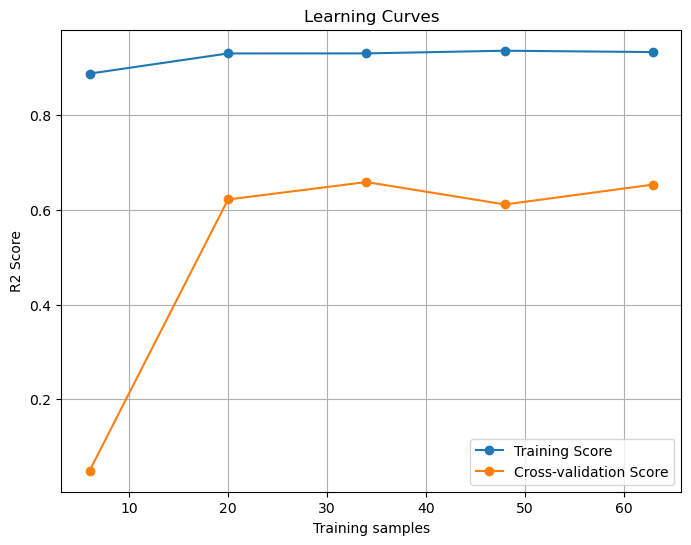

In [5]:
train_sizes, train_scores, test_scores = learning_curve(
 pipeline, x_test, y_test, cv=5, scoring='r2', n_jobs=-1
)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Cross-validation Score')
plt.xlabel('Training samples')
plt.ylabel('R2 Score')
plt.title('Learning Curves')
plt.legend()
plt.grid(True)
plt.show()

Biểu đồ trên cho thấy đường cross-validation score tăng dần và thu nhỏ khoảng cách với đường training score. Mô hình hiện tại đã đạt hiệu suất tốt (R2>0.85) và đủ điều kiện để đưa vào sử dụng. Vì đường Cross-validation R2 vẫn đang có xu hướng tăng dần ở đoạn cuối biểu đồ, ta có thể kết luận rằng mô hình vẫn còn "đói" dữ liệu. Nếu có thể bổ sung thêm dữ liệu, độ chính xác của mô hình chắc chắn sẽ còn tiếp tục được cải thiện.

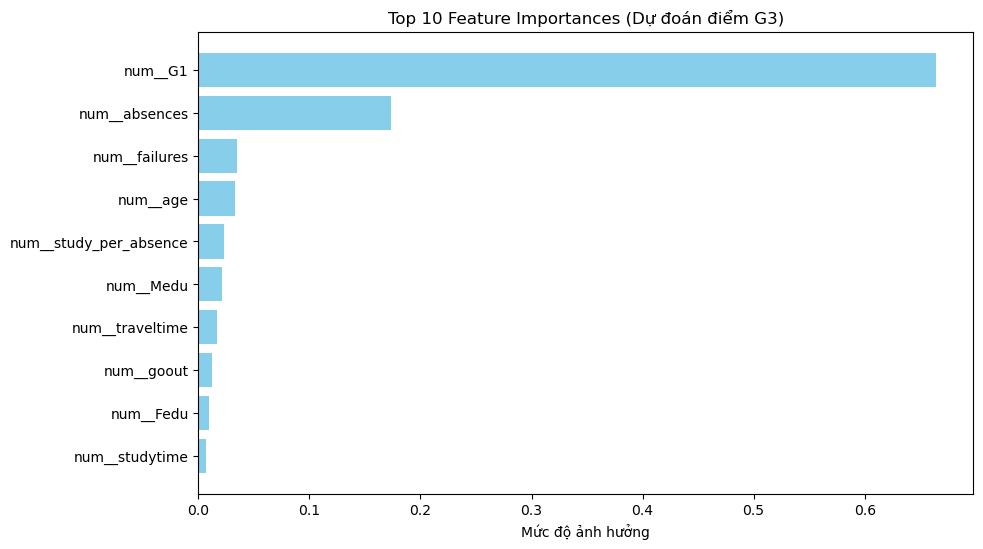

In [6]:
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()
importances = pipeline.named_steps['model'].feature_importances_

# Sắp xếp và lấy Top 10
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances (Dự đoán điểm G3)')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Mức độ ảnh hưởng')
plt.show()

Qua biểu đồ trên, ta thấy điểm thi kỳ 1 (num_G1) đóng góp rất lớn trong vai trò dự đoán (hơn 60%). Số buổi nghỉ ảnh hưởng lớn đến kết quả
